# Projeto Previsão Vendas de E-Commerce

Usaremos como fonte de dados o dataset: Online Shoppers Purchasing Intention Dataset
https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset

O conjunto de dados consiste em valores de recursos pertencentes a 12.330 sessões online. O conjunto de dados foi formado de modo que cada sessão pertença a um usuário diferente em um período de 1 ano para evitar qualquer tendência para uma campanha específica, dia especial, usuário, perfil ou período.

O conjunto de dados consiste em 10 atributos numéricos e 8 categóricos. O atributo 'Revenue' pode ser usado como o rótulo da classe, ou seja, nossa variável ALVO

### Dicionário de dados: Descrição a que se refere cada variável do conjunto de dados


"Administrativo", "Duração administrativa", "Informativo", "Duração informativo", "Relacionado ao produto" e "Duração relacionada ao produto" representam o número de diferentes tipos de páginas visitadas pelo visitante nessa sessão e o tempo total gasto em cada uma dessas categorias de página. Os valores desses recursos são derivados das informações de URL das páginas visitadas pelo usuário e atualizadas em tempo real quando um usuário executa uma ação, por exemplo, passando de uma página para outra. 

Os recursos "Taxa de rejeição", "Taxa de saída" e "Valor da página" representam as métricas medidas pelo "Google Analytics" para cada página no site de comércio eletrônico. 

O valor do recurso "Taxa de rejeição" de uma página da web refere-se à porcentagem de visitantes que entram no site a partir dessa página e saem ("rejeição") sem acionar outras solicitações ao servidor durante essa sessão. 

O valor do recurso "Taxa de saída" para uma página da web específica é calculado como a porcentagem que foi a última na sessão, para todas as exibições de página a página. 

O recurso "Valor da página" representa o valor médio para uma página da web que um usuário visitou antes de concluir uma transação de comércio eletrônico. 

O recurso "Dia especial" indica a proximidade do horário de visita do site a um dia especial específico (por exemplo, dia das mães, dia dos namorados) em que as sessões têm mais probabilidade de serem finalizadas com a transação. O valor desse atributo é determinado considerando a dinâmica do comércio eletrônico, como a duração entre a data do pedido e a data de entrega. Por exemplo, no dia dos namorados, esse valor assume um valor diferente de zero entre 2 e 12 de fevereiro (dia dos namorados nos EUA e Europa), zero antes e depois dessa data, a menos que esteja próximo de outro dia especial e seu valor máximo de 1 em 8 de fevereiro. 

O conjunto de dados também inclui o tipo de sistema operacional, navegador, região, tipo de tráfego, tipo de visitante como visitante novo ou recorrente, um valor booleano indicando se a data da visita é final de semana e mês do ano.

A variável alvo (Revenue) é booleana, com True se a sessão gerou receita e False se não gerou.

### Objetivo

Avaliar quais são os 3 atributos que mais influenciam um usuário na compra de produtos online e construir um modelo preditivo para realizar previsões de compras futuras.

O responsável pela solicitação do projeto solicitou uma tabela demonstrativa com no mínimo 3 tipos de testes de modelos para corroborar nosso trabalho.

In [1]:
# Bibliotecas

import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn import svm


from imblearn import under_sampling, over_sampling
from imblearn.over_sampling import SMOTE

from category_encoders.one_hot import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

import sklearn
import matplotlib
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings('ignore', category=DeprecationWarning)

from config import data, imagem


### Coleta e Análise de Dados

In [2]:
# Carregando dados

df = pd.read_csv(data/'online_shoppers_intention.csv')

In [3]:
# Visualizando os dados

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0.0,0.0,0.0,0.0,1.0,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0.0,0.0,0.0,0.0,2.0,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0.0,-1.0,0.0,-1.0,1.0,-1.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0.0,0.0,0.0,0.0,2.0,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0.0,0.0,0.0,0.0,10.0,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
# Tamanho dos dados

df.shape

(12330, 18)

In [5]:
# Tipo dos dados

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12316 non-null  float64
 1   Administrative_Duration  12316 non-null  float64
 2   Informational            12316 non-null  float64
 3   Informational_Duration   12316 non-null  float64
 4   ProductRelated           12316 non-null  float64
 5   ProductRelated_Duration  12316 non-null  float64
 6   BounceRates              12316 non-null  float64
 7   ExitRates                12316 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [6]:
# Validando qtd nulos

df.isnull().sum()

Administrative             14
Administrative_Duration    14
Informational              14
Informational_Duration     14
ProductRelated             14
ProductRelated_Duration    14
BounceRates                14
ExitRates                  14
PageValues                  0
SpecialDay                  0
Month                       0
OperatingSystems            0
Browser                     0
Region                      0
TrafficType                 0
VisitorType                 0
Weekend                     0
Revenue                     0
dtype: int64

In [7]:
# Como o volume é pouco, removeremos os valores nulos

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

In [8]:
# Validando se os nulos sumiram

df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [9]:
# Verificando valores unicos

df.nunique()

Administrative               27
Administrative_Duration    3336
Informational                17
Informational_Duration     1259
ProductRelated              311
ProductRelated_Duration    9552
BounceRates                1872
ExitRates                  4777
PageValues                 2704
SpecialDay                    6
Month                        10
OperatingSystems              8
Browser                      13
Region                        9
TrafficType                  20
VisitorType                   3
Weekend                       2
Revenue                       2
dtype: int64

In [10]:
# Vamos separar em variáveis categóricas e continuas.
# Categórtica será todas com menos de 30

variaveis_continuas = []
variaveis_categoricas = []

for col in df.columns[:-1]:
    if df.nunique()[col] >= 30:
        variaveis_continuas.append(col)
    else:
        variaveis_categoricas.append(col)

In [11]:
# Variaveis continuas
df[variaveis_continuas].head()

,Administrative_Duration,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues
0,0.0,0.0,1.0,0.000000,0.20,0.20,0.0
1,0.0,0.0,2.0,64.000000,0.00,0.10,0.0
2,-1.0,-1.0,1.0,-1.000000,0.20,0.20,0.0
3,0.0,0.0,2.0,2.666667,0.05,0.14,0.0
4,0.0,0.0,10.0,627.500000,0.02,0.05,0.0


In [12]:
# variaveis categoricas

df[variaveis_categoricas].head()

,Administrative,Informational,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,0.0,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False
1,0.0,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False
2,0.0,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False
3,0.0,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False
4,0.0,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True


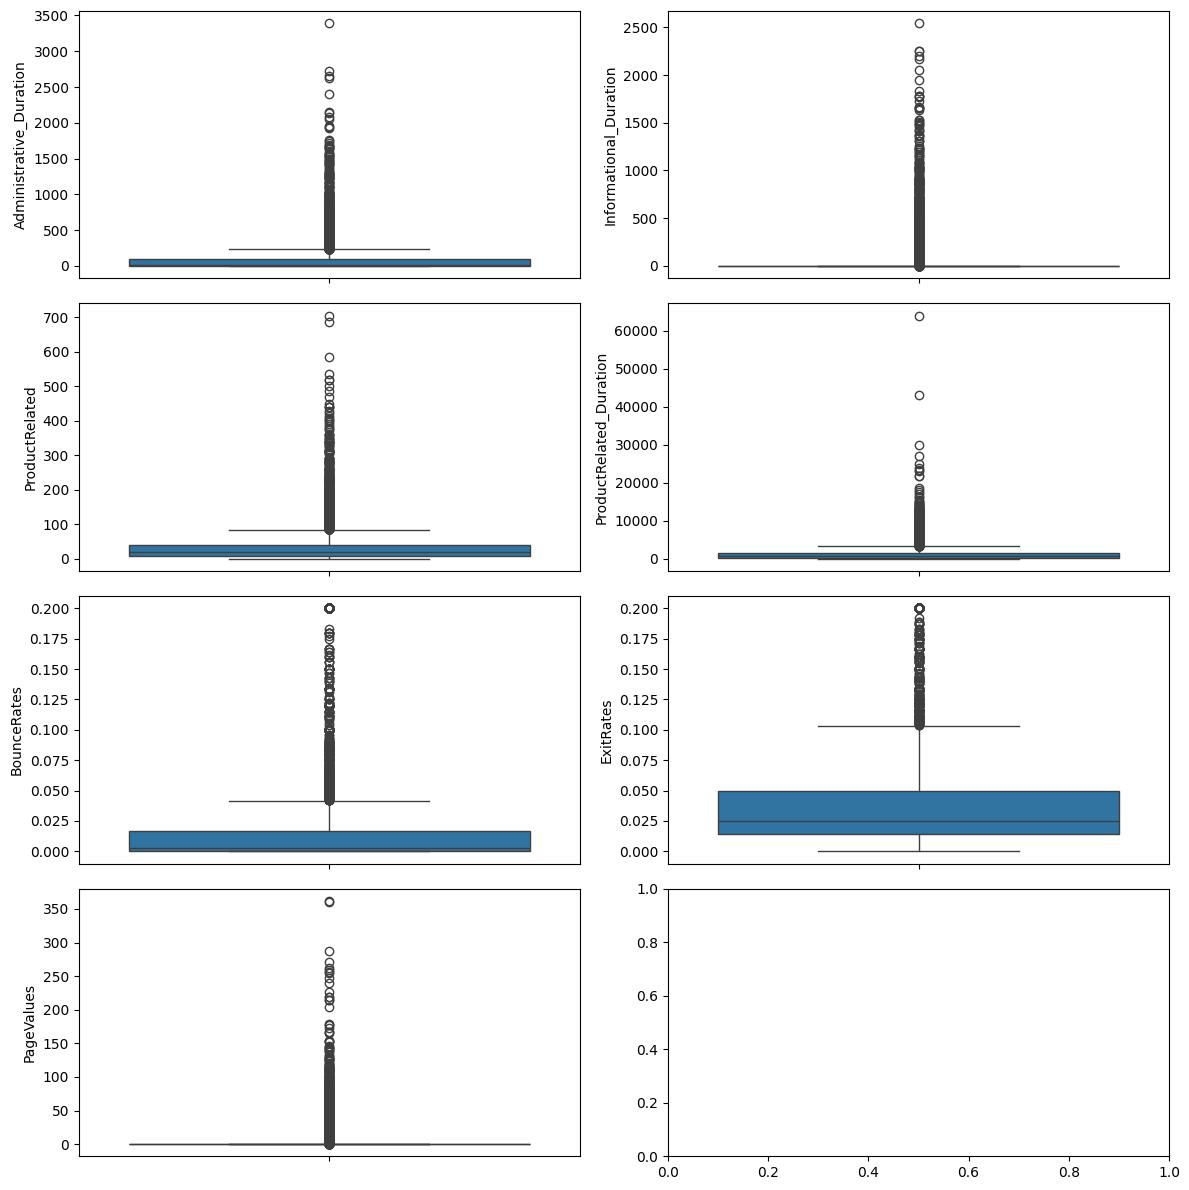

In [13]:
# Gerando boxplots para analise das variáveis continuas

plt.rcParams['figure.figsize'] = [12.00, 12.00]
plt.rcParams['figure.autolayout'] = True
f, axes = plt.subplots(4,2)

linha = 0
coluna = 0

for i in variaveis_continuas:
    sns.boxplot(data = df, y=i, ax=axes[linha][coluna])

    coluna += 1
    if coluna == 2:
        linha += 1
        coluna = 0

plt.savefig(imagem/'boxplot.png')
plt.show();

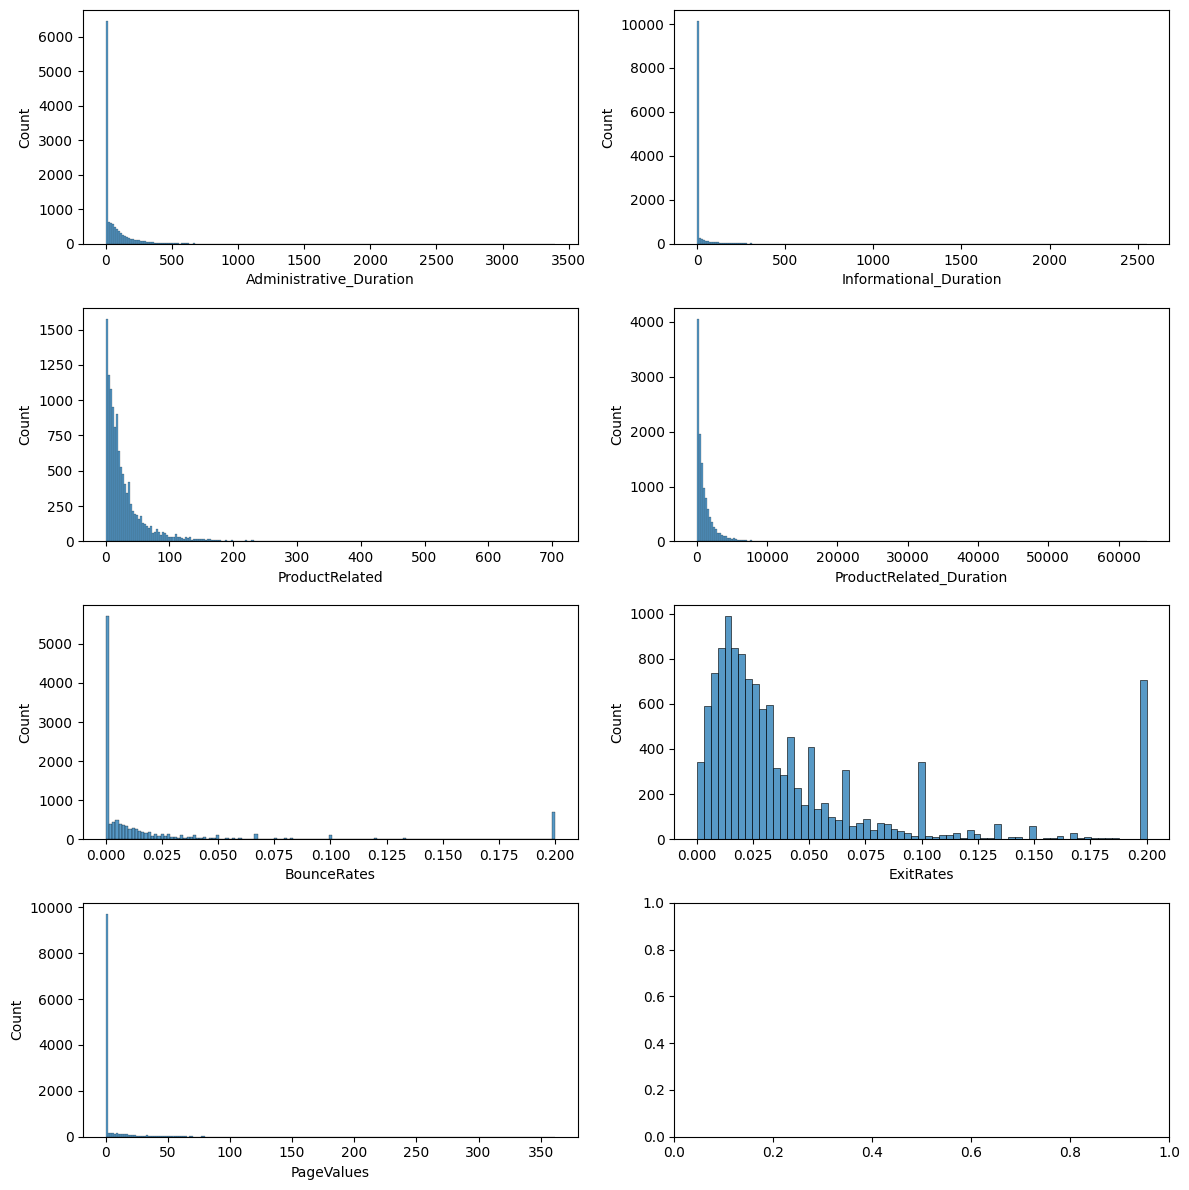

In [14]:
# Gerando histograma

# Gerando boxplots para analise das variáveis continuas

plt.rcParams['figure.figsize'] = [12.00, 12.00]
plt.rcParams['figure.autolayout'] = True
f, axes = plt.subplots(4,2)

linha = 0
coluna = 0

for i in variaveis_continuas:
    sns.histplot(data = df, x=i, ax=axes[linha][coluna])

    coluna += 1
    if coluna == 2:
        linha += 1
        coluna = 0

plt.savefig(imagem/'histplot.png')
plt.show();

In [15]:
# Aplicar o QuantileTransformer nas colunas numéricas

qt = QuantileTransformer(output_distribution='normal', random_state=42)
df[variaveis_continuas] = qt.fit_transform(df[variaveis_continuas])

In [16]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0.0,-0.703922,0.0,-0.243255,-1.918441,-1.858747,5.199338,5.199338,-5.199338,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0.0,-0.703922,0.0,-0.243255,-1.467860,-1.116369,-5.199338,1.261282,-5.199338,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0.0,-5.199338,0.0,-5.199338,-1.918441,-5.199338,5.199338,5.199338,-5.199338,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0.0,-0.703922,0.0,-0.243255,-1.467860,-1.546460,1.225943,1.482760,-5.199338,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0.0,-0.703922,0.0,-0.243255,-0.457033,0.018246,0.774833,0.708752,-5.199338,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


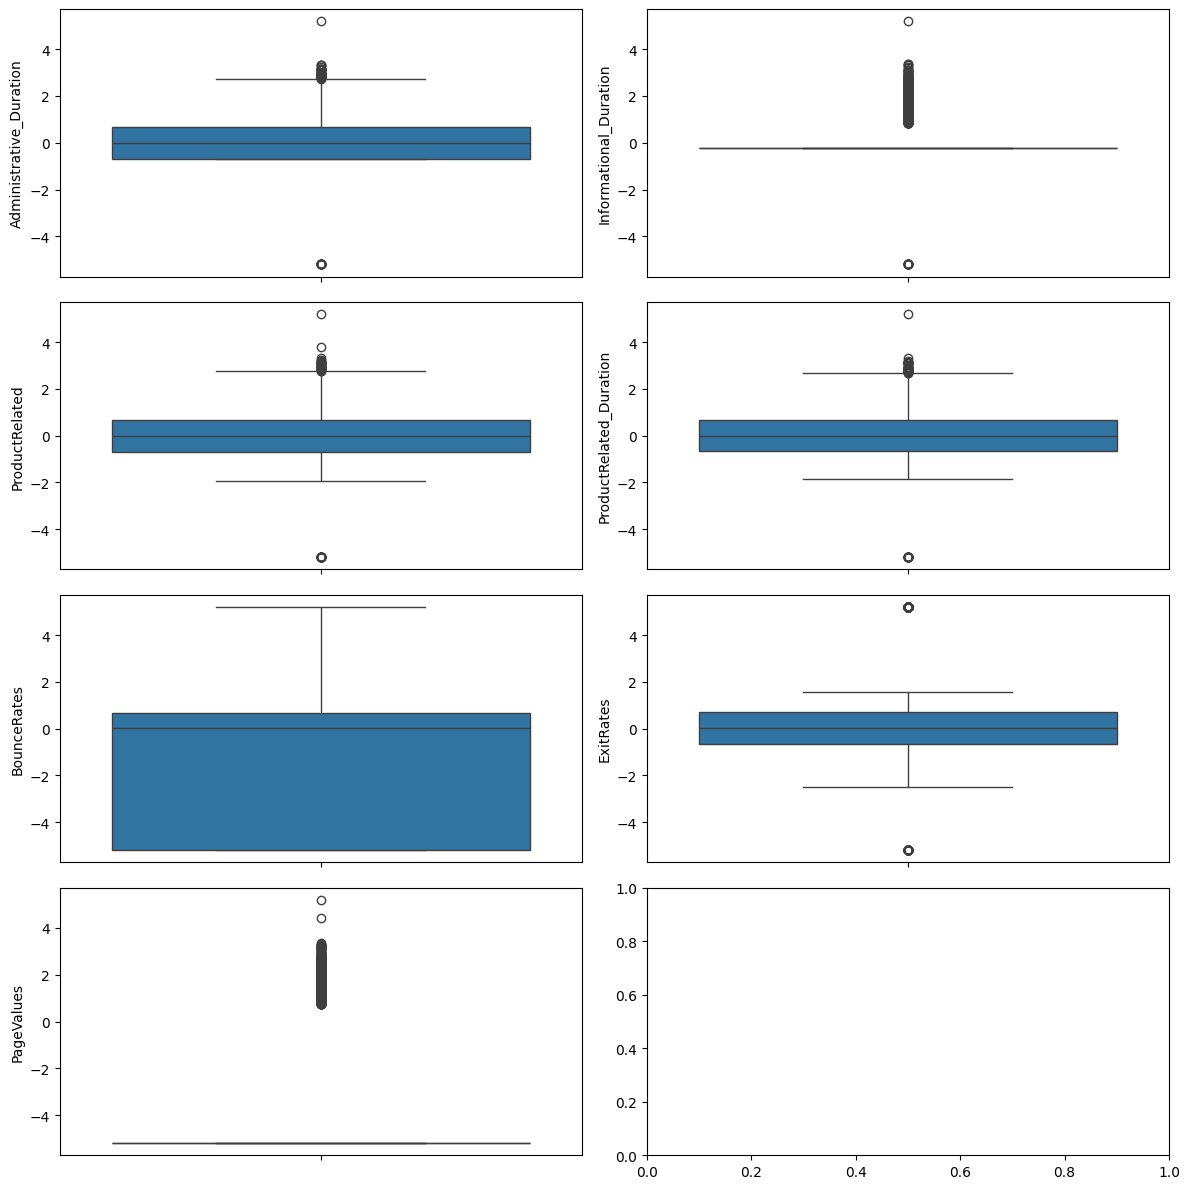

In [17]:
# Gerando boxplots para analise das variáveis continuas

plt.rcParams['figure.figsize'] = [12.00, 12.00]
plt.rcParams['figure.autolayout'] = True
f, axes = plt.subplots(4,2)

linha = 0
coluna = 0

for i in variaveis_continuas:
    sns.boxplot(data = df, y=i, ax=axes[linha][coluna])

    coluna += 1
    if coluna == 2:
        linha += 1
        coluna = 0

plt.savefig(imagem/'boxplot.png')
plt.show();

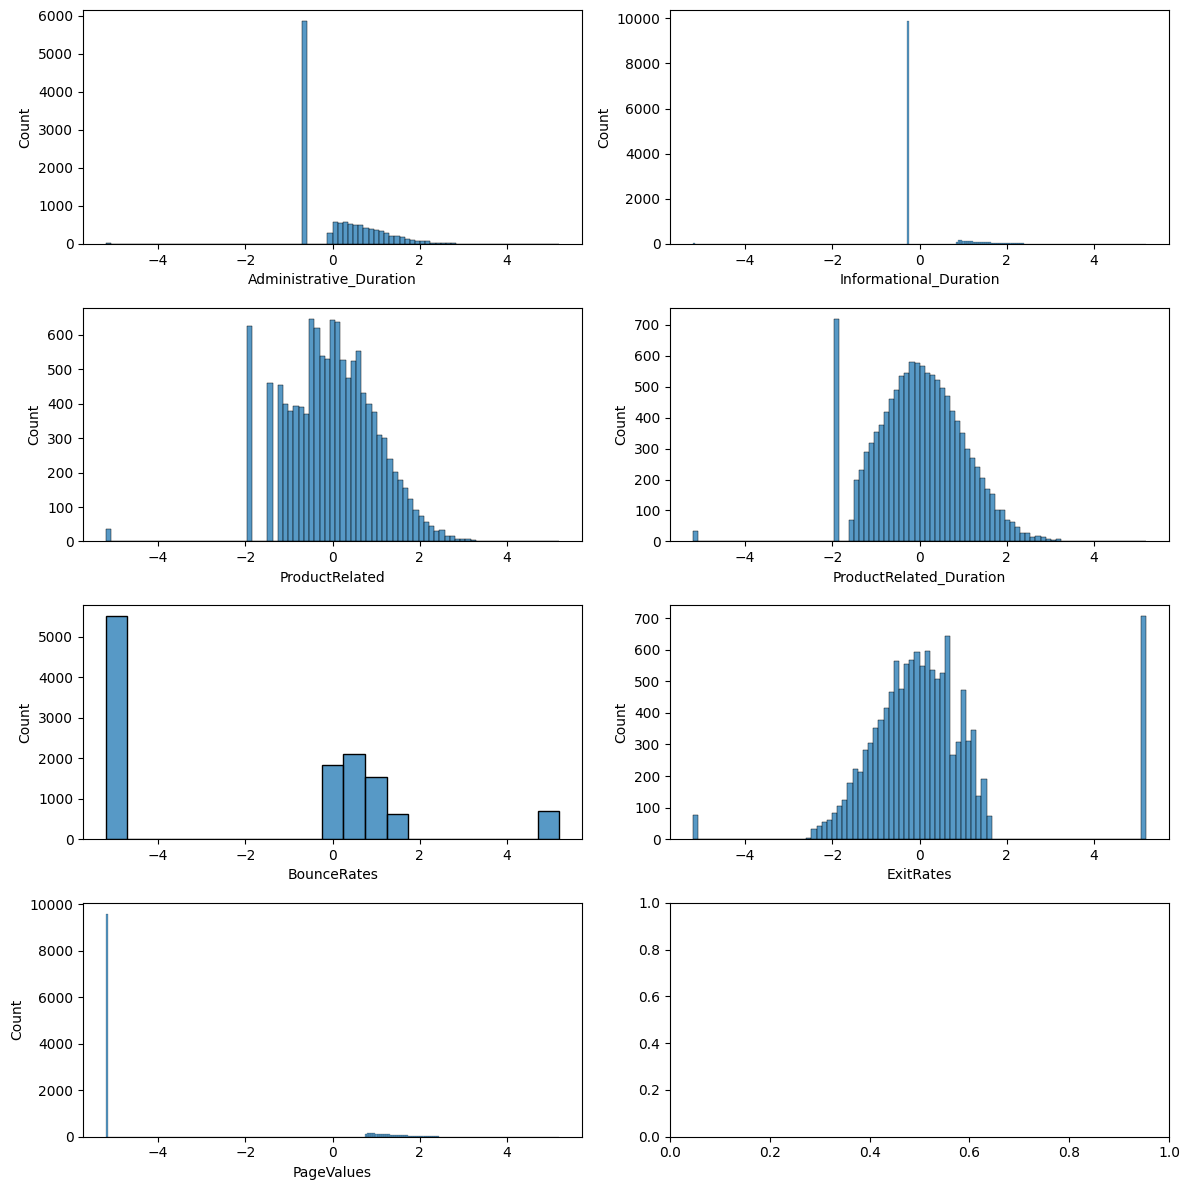

In [18]:
# Gerando histograma

# Gerando boxplots para analise das variáveis continuas

plt.rcParams['figure.figsize'] = [12.00, 12.00]
plt.rcParams['figure.autolayout'] = True
f, axes = plt.subplots(4,2)

linha = 0
coluna = 0

for i in variaveis_continuas:
    sns.histplot(data = df, x=i, ax=axes[linha][coluna])

    coluna += 1
    if coluna == 2:
        linha += 1
        coluna = 0

plt.savefig(imagem/'histplot.png')
plt.show();

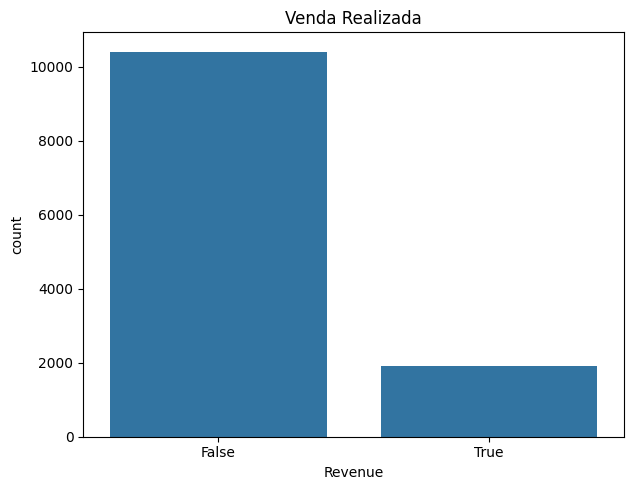

In [19]:
# Countplot Venda ou Não
plt.rcParams['figure.figsize'] = [12.00, 5.00]
plt.rcParams['figure.autolayout'] = True

plt.subplot(1,2,2)
plt.title('Venda Realizada')
sns.countplot(x=df['Revenue'])
plt.show();

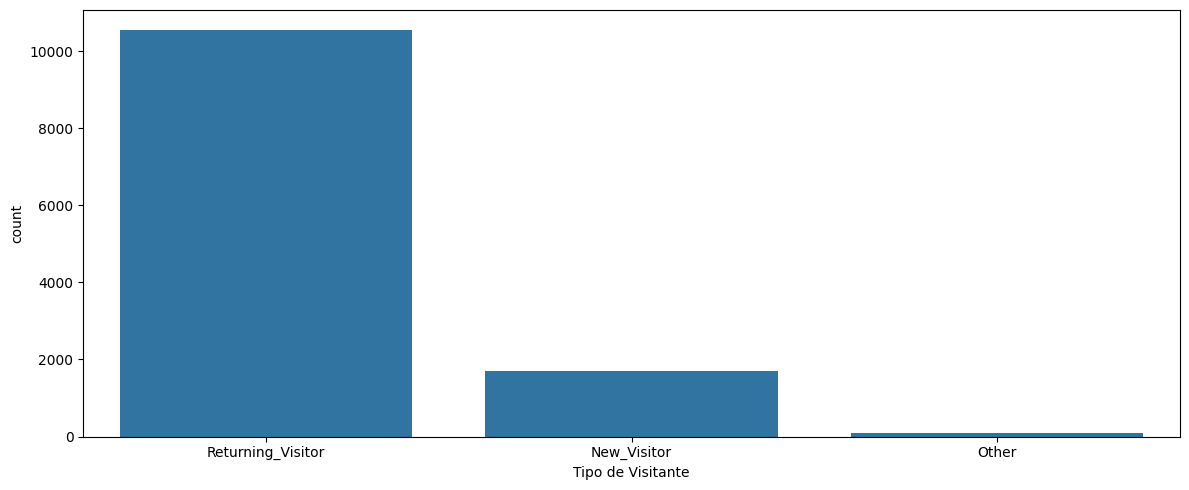

In [20]:
# Countplot Tipo de Visitante

plt.xlabel('Tipo de Visitante')
sns.countplot(x = df['VisitorType'])
plt.show();

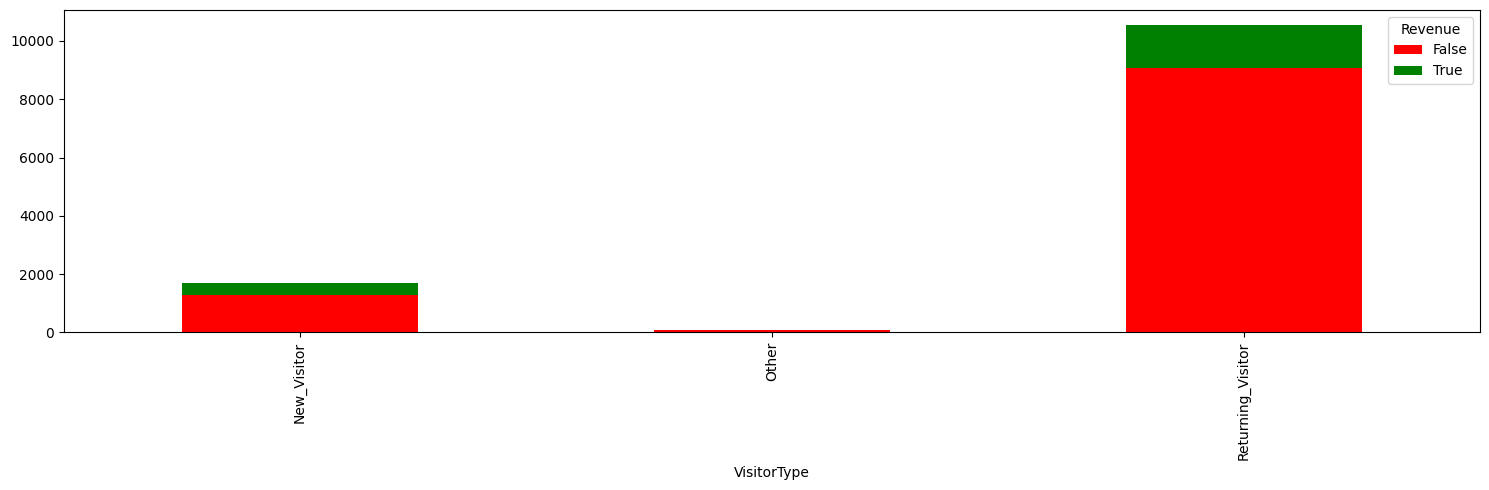

In [21]:
# Stacked Bar Tipo de vistante x revenue

pd.crosstab(df['VisitorType'], df['Revenue']).plot(kind='bar',
                                                   stacked=True,
                                                   figsize=(15,5),
                                                   color = ['red', 'green'])
plt.show();

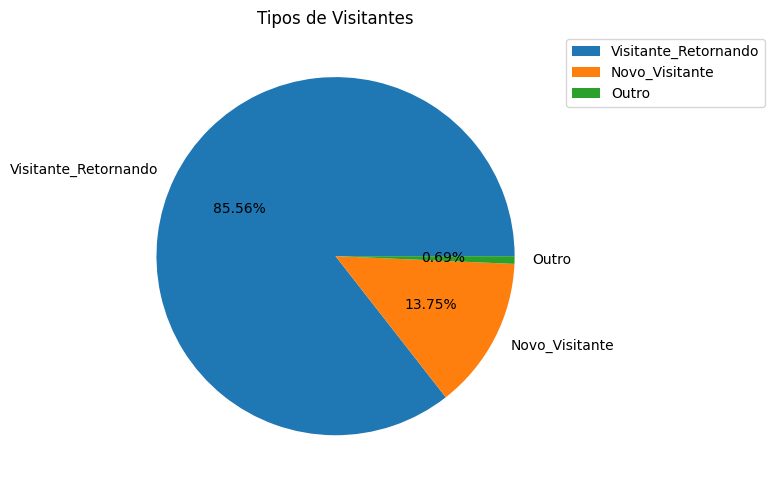

In [22]:
# Gráfico de pizza de tipos de visitantes

labels = ['Visitante_Retornando', 'Novo_Visitante', 'Outro']
plt.title('Tipos de Visitantes')
plt.pie(df['VisitorType'].value_counts(), labels=labels, autopct='%.2f%%')
plt.legend(bbox_to_anchor=(1,1))
plt.show();

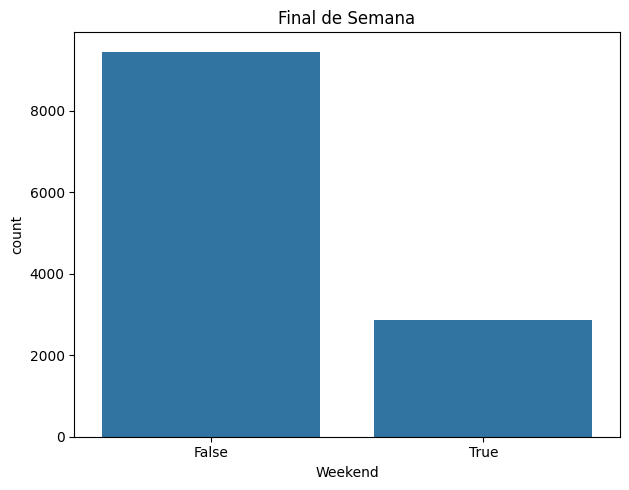

In [23]:
# Countplot Final de Semana sim ou não

plt.subplot(1,2,1)
plt.title('Final de Semana')
sns.countplot(x=df['Weekend'])
plt.show();

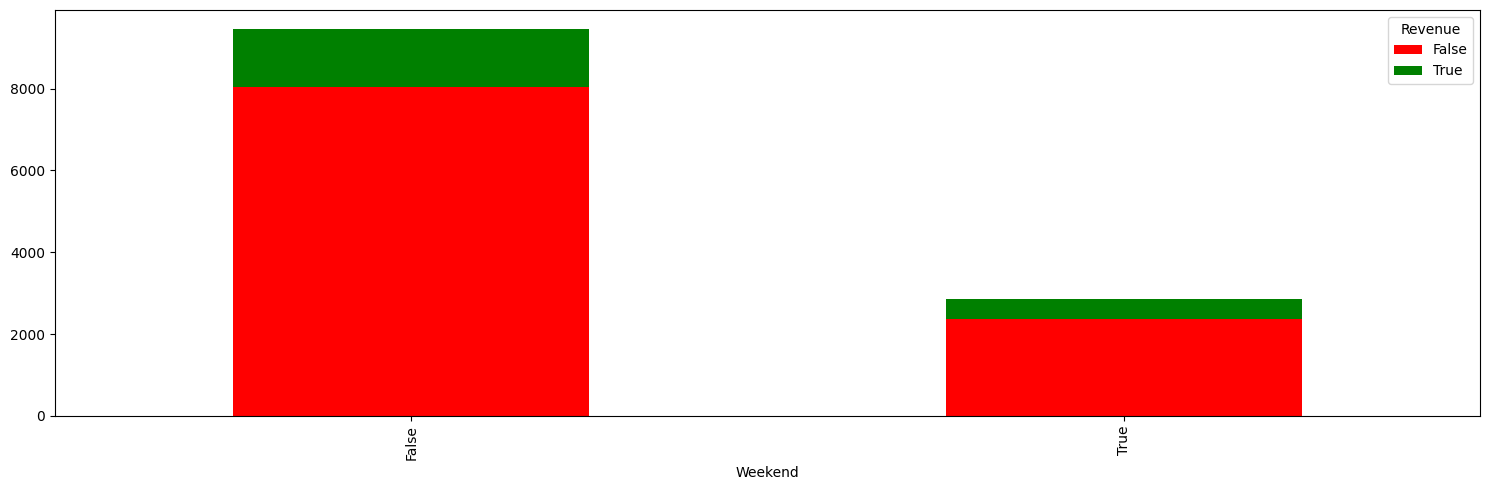

In [24]:
# Stacked Bar Tipo de Semana x Revemue

pd.crosstab(df['Weekend'], df['Revenue']).plot(kind='bar',
                                                   stacked=True,
                                                   figsize=(15,5),
                                                   color = ['red', 'green'])
plt.show();

# Preparação para Processamento

Vamos transformar as variáveis ordinais através do ordinalencoder e as categóricas através do onehotencoder

In [25]:
# Carregando as variáveis categóricas ordinais

variaveis_categoricas_ordinais = ['Month']

# Realizando o ordinal encoder

encoder = OrdinalEncoder()
for var in variaveis_categoricas_ordinais:
    df[var] = encoder.fit_transform(df[var])

In [26]:
# Variaveis categoricas nominais

variaveis_categoricas_nominais = ['VisitorType', 'Weekend']

In [27]:
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df[variaveis_categoricas_nominais])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(variaveis_categoricas_nominais))
df = pd.concat([df,one_hot_df], axis=1)
df = df.drop(variaveis_categoricas_nominais, axis=1)

In [28]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,OperatingSystems,Browser,Region,TrafficType,Revenue,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_False,Weekend_True
0,0.0,-0.703922,0.0,-0.243255,-1.918441,-1.858747,5.199338,5.199338,-5.199338,0.0,...,1,1,1,1,False,0.0,0.0,1.0,1.0,0.0
1,0.0,-0.703922,0.0,-0.243255,-1.467860,-1.116369,-5.199338,1.261282,-5.199338,0.0,...,2,2,1,2,False,0.0,0.0,1.0,1.0,0.0
2,0.0,-5.199338,0.0,-5.199338,-1.918441,-5.199338,5.199338,5.199338,-5.199338,0.0,...,4,1,9,3,False,0.0,0.0,1.0,1.0,0.0
3,0.0,-0.703922,0.0,-0.243255,-1.467860,-1.546460,1.225943,1.482760,-5.199338,0.0,...,3,2,2,4,False,0.0,0.0,1.0,1.0,0.0
4,0.0,-0.703922,0.0,-0.243255,-0.457033,0.018246,0.774833,0.708752,-5.199338,0.0,...,3,3,1,4,False,0.0,0.0,1.0,0.0,1.0


In [29]:
# Verificando se a variável alvo está balanceada

target_count = df['Revenue'].count()
target_count

np.int64(12316)

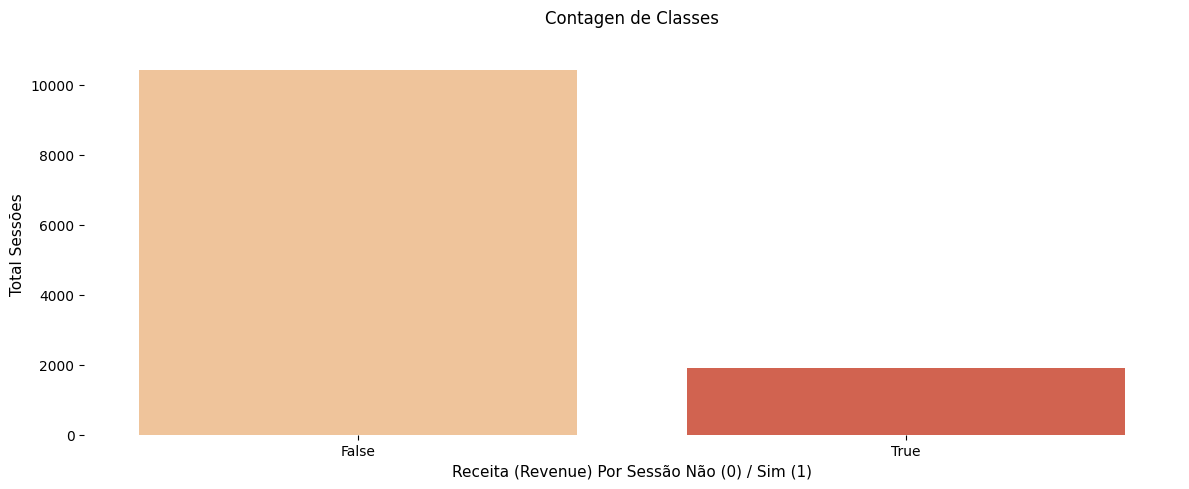

In [30]:
# Vendo Graficamente o balanceamento

sns.countplot(x=df['Revenue'], palette='OrRd')
plt.box(False)
plt.xlabel('Receita (Revenue) Por Sessão Não (0) / Sim (1)', fontsize=11)
plt.ylabel('Total Sessões', fontsize=11)
plt.title('Contagen de Classes\n')
plt.show();

In [31]:
# Separando variaveis preditoras da alvo

preditora = df.drop(['Revenue'], axis = 1)
target = df['Revenue'].copy()

In [32]:
# Balanceando a variável alvo

balanceador = SMOTE(random_state=42)

preditora_bal, target_bal = balanceador.fit_resample(preditora, target)

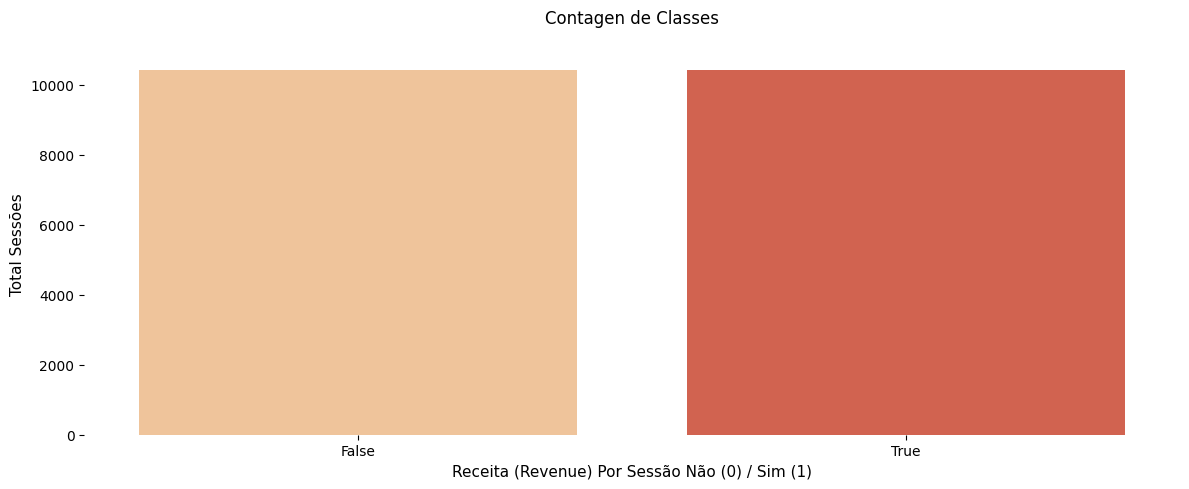

In [34]:
# Vendo Graficamente o novo balanceamento

sns.countplot(x=target_bal, palette='OrRd')
plt.box(False)
plt.xlabel('Receita (Revenue) Por Sessão Não (0) / Sim (1)', fontsize=11)
plt.ylabel('Total Sessões', fontsize=11)
plt.title('Contagen de Classes\n')
plt.show();

In [35]:
# Tamanho das variaveis balanceades

print('Tamanho da preditora antes: ',preditora.shape)
print('Tamanho da preditora depois: ',preditora_bal.shape)
print('Tamanho da alvo antes: ',target.shape)
print('Tamanho da alvo depois: ',target_bal.shape)

Tamanho da preditora antes:  (12316, 20)
Tamanho da preditora depois:  (20816, 20)
Tamanho da alvo antes:  (12316,)
Tamanho da alvo depois:  (20816,)


### Começando Processo de Predição

In [36]:
# Separando entre treino e teste

x_treino, x_teste, y_treino, y_teste = train_test_split(preditora_bal, target_bal, test_size=0.3, random_state=42)

In [37]:
# Criar modelo

modelo_v1 = svm.SVC(kernel='linear')

In [38]:
# Treinamento Inicial do Modelo

modelo_v1.fit(x_treino, y_treino)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [39]:
# Gerando as previsoes

prev_v1 = modelo_v1.predict(x_teste)

In [42]:
# Dicionario de métricas e metadados

svm_dict_v1 = {'Modelo':'SVM',
               'Versão':'1',
               'Kernel':'Linear',
               'Precision':precision_score(prev_v1, y_teste),
               'Recall':recall_score(prev_v1, y_teste),
               'F1 Score':f1_score(prev_v1, y_teste),
               'Acurácia':accuracy_score(prev_v1, y_teste),
               'AUC':roc_auc_score(y_teste, prev_v1)}

In [43]:
# Visualizando as métricas

print('Métricas em Teste:\n')
svm_dict_v1

Métricas em Teste:



{'Modelo': 'SVM',
 'Versão': '1',
 'Kernel': 'Linear',
 'Precision': 0.8054499366286438,
 'Recall': 0.8735395189003436,
 'F1 Score': 0.8381140784701615,
 'Acurácia': 0.8427542033626901,
 'AUC': 0.8431587656597411}

In [44]:
# Padronizando os dados

sc = StandardScaler()

x_treino_padronizado = sc.fit_transform(x_treino)
x_teste_padronizado = sc.fit_transform(x_teste)

In [46]:
# Treinamento Inicial do Modelo

modelo_v2 = svm.SVC(kernel='linear')
modelo_v2.fit(x_treino_padronizado, y_treino)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [47]:
# Gerando as previsoes

prev_v2 = modelo_v2.predict(x_teste)

In [49]:
# Dicionario de métricas e metadados

svm_dict_v2 = {'Modelo':'SVM',
               'Versão':'1',
               'Kernel':'Linear',
               'Precision':precision_score(prev_v2, y_teste),
               'Recall':recall_score(prev_v2, y_teste),
               'F1 Score':f1_score(prev_v2, y_teste),
               'Acurácia':accuracy_score(prev_v2, y_teste),
               'AUC':roc_auc_score(y_teste, prev_v2)}

In [50]:
# Visualizando as métricas

print('Métricas em Teste:\n')
svm_dict_v2

Métricas em Teste:



{'Modelo': 'SVM',
 'Versão': '1',
 'Kernel': 'Linear',
 'Precision': 0.802915082382763,
 'Recall': 0.8731909028256375,
 'F1 Score': 0.8365797292835919,
 'Acurácia': 0.8414731785428343,
 'AUC': 0.8418913385368006}

### Otimizando Hiperparâmetros com Grid Search e Kernel RBF

In [51]:
# Cria o modelo
modelo_v3 = svm.SVC(kernel = 'rbf')

# Valores para o grid
C_range = np.array([50., 100., 200.])
gamma_range = np.array([0.3*0.001,0.001,3*0.001])

# Grid de hiperparâmetros
svm_param_grid = dict(gamma = gamma_range, C = C_range)

# Grid Search
modelo_v3_grid_search_rbf = GridSearchCV(modelo_v3, svm_param_grid, cv = 3)

# Treinamento
modelo_v3_grid_search_rbf.fit(x_treino_padronizado, y_treino)

# Acurácia em Treino
print(f"Acurácia em Treinamento: {modelo_v3_grid_search_rbf.best_score_ :.2%}")
print("")
print(f"Hiperparâmetros Ideais: {modelo_v3_grid_search_rbf.best_params_}")

Acurácia em Treinamento: 88.01%

Hiperparâmetros Ideais: {'C': np.float64(200.0), 'gamma': np.float64(0.003)}


In [52]:
# Gerando as Previsões do Modelo V3
previsoes_v3 = modelo_v3_grid_search_rbf.predict(x_teste_padronizado)

In [53]:
# Dicionário de métricas e metadados
svm_dict_v3 = {'Modelo':'SVM',
               'Versão':'3',
               'Kernel':'RBF com Dados Padronizados',
               'Precision':precision_score(previsoes_v3, y_teste),
               'Recall':recall_score(previsoes_v3, y_teste),
               'F1 Score':f1_score(previsoes_v3, y_teste),
               'Acurácia':accuracy_score(previsoes_v3, y_teste),
               'AUC':roc_auc_score(y_teste, previsoes_v3)}

In [54]:
# Visualizando as Métricas
print("Métricas em Teste:\n")
svm_dict_v3

Métricas em Teste:



{'Modelo': 'SVM',
 'Versão': '3',
 'Kernel': 'RBF com Dados Padronizados',
 'Precision': 0.8697718631178707,
 'Recall': 0.8874878758486906,
 'F1 Score': 0.8785405664906385,
 'Acurácia': 0.8784627702161729,
 'AUC': 0.8785570225268861}

In [55]:
# Cria o modelo
modelo_v4 = svm.SVC(kernel = 'poly')

# Valores para o grid
r_range =  np.array([0.5, 1])
gamma_range =  np.array([0.001, 0.01])
d_range = np.array([2,3, 4])

# Grid de hiperparâmetros
param_grid_poly = dict(gamma = gamma_range, degree = d_range, coef0 = r_range)

# Grid Search
modelo_v4_grid_search_poly = GridSearchCV(modelo_v4, param_grid_poly, cv = 3)

# Treinamento
modelo_v4_grid_search_poly.fit(x_treino_padronizado, y_treino)

# Acurácia em Treino
print(f"Acurácia em Treinamento: {modelo_v4_grid_search_poly.best_score_ :.2%}")
print("")
print(f"Hiperparâmetros Ideais: {modelo_v4_grid_search_poly.best_params_}")

Acurácia em Treinamento: 85.95%

Hiperparâmetros Ideais: {'coef0': np.float64(1.0), 'degree': np.int64(4), 'gamma': np.float64(0.01)}


In [56]:
# Gerando as previsões do Modelo V4
previsoes_v4 = modelo_v4_grid_search_poly.predict(x_teste_padronizado)

In [57]:
# Dicionário de métricas
svm_dict_v4 = {'Modelo':'SVM',
               'Versão':'4',
               'Kernel':'Polinomial com Dados Padronizados',
               'Precision':precision_score(previsoes_v4, y_teste),
               'Recall':recall_score(previsoes_v4, y_teste),
               'F1 Score':f1_score(previsoes_v4, y_teste),
               'Acurácia':accuracy_score(previsoes_v4, y_teste),
               'AUC':roc_auc_score(y_teste, previsoes_v4)}

In [58]:
# Visualizando as Métricas
print("Métricas em Teste:\n")
svm_dict_v4

Métricas em Teste:



{'Modelo': 'SVM',
 'Versão': '4',
 'Kernel': 'Polinomial com Dados Padronizados',
 'Precision': 0.8453738910012675,
 'Recall': 0.8814007267922035,
 'F1 Score': 0.8630114830988194,
 'Acurácia': 0.8643714971977582,
 'AUC': 0.8645775249761921}

In [59]:
# Concatena todos os dicionários em um dataframe do Pandas
resumo = pd.DataFrame({'SVM_Modelo_1':pd.Series(svm_dict_v1),
                       'SVM_Modelo_2':pd.Series(svm_dict_v2),
                       'SVM_Modelo_3':pd.Series(svm_dict_v3),
                       'SVM_Modelo_4':pd.Series(svm_dict_v4)})

In [60]:
# Visualiza o resumo de todas métricas de todos modelos
resumo

,SVM_Modelo_1,SVM_Modelo_2,SVM_Modelo_3,SVM_Modelo_4
Modelo,SVM,SVM,SVM,SVM
Versão,1,1,3,4
Kernel,Linear,Linear,RBF com Dados Padronizados,Polinomial com Dados Padronizados
Precision,0.802915,0.802915,0.869772,0.845374
Recall,0.873191,0.873191,0.887488,0.881401
F1 Score,0.83658,0.83658,0.878541,0.863011
Acurácia,0.841473,0.841473,0.878463,0.864371
AUC,0.841891,0.841891,0.878557,0.864578


In [61]:
# Biblioteca para avaliar as variaveis mais importantes do modelo
from sklearn.inspection import permutation_importance

In [62]:
# Cria o modelo V3 com os hiperparametros encontrados no GridSearch
modelo_v3 = svm.SVC(kernel = 'rbf', C = 200.0, gamma = 0.003)
modelo_v3.fit(x_treino_padronizado, y_treino)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",200.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.003
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [63]:
# visualizando as variaveis mais importantes
perm_importance = permutation_importance(modelo_v3, x_teste_padronizado, y_teste)
variaveis_preditoras = preditora.columns

importancia = perm_importance.importances_mean.argsort()
importancia_svm = pd.Series(data=perm_importance.importances_mean[importancia], index=variaveis_preditoras[importancia])
importancia_svm.sort_values(ascending = False)

PageValues                       0.296942
Weekend_False                    0.116317
Weekend_True                     0.116317
VisitorType_Returning_Visitor    0.082274
VisitorType_New_Visitor          0.069271
ExitRates                        0.012074
ProductRelated_Duration          0.007686
ProductRelated                   0.007270
SpecialDay                       0.005893
Administrative                   0.005092
OperatingSystems                 0.004708
Informational                    0.003715
VisitorType_Other                0.003651
Month                            0.003331
Informational_Duration           0.002306
Region                           0.001697
Administrative_Duration          0.001505
TrafficType                      0.001505
Browser                          0.001409
BounceRates                      0.001377
dtype: float64

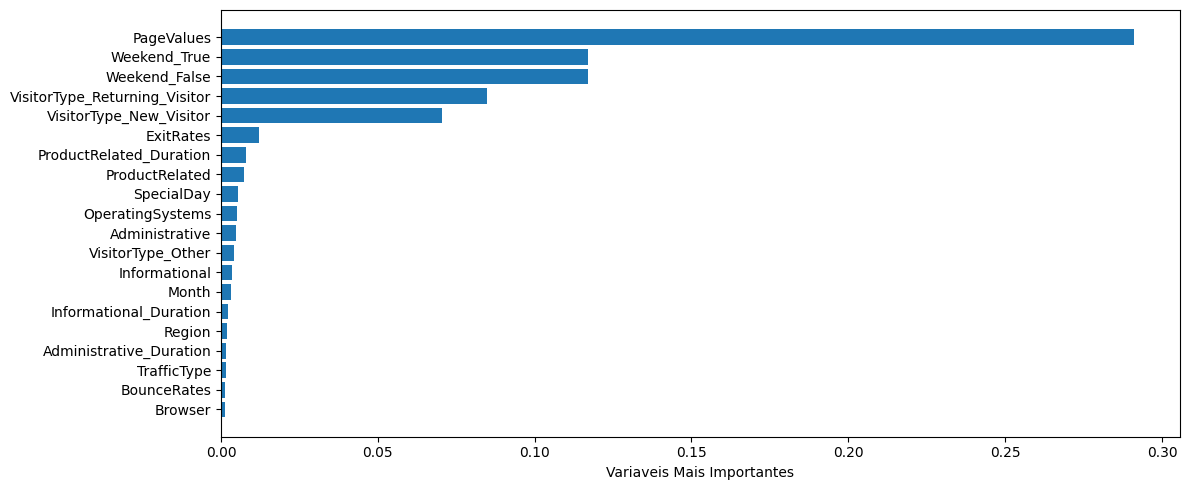

In [64]:
# Gerando um gráfico das variáveis mais importantes
perm_importance = permutation_importance(modelo_v3, x_teste_padronizado, y_teste)

variaveis_preditoras = preditora.columns
variaveis = np.array(variaveis_preditoras)


importancia = perm_importance.importances_mean.argsort()
plt.barh(variaveis_preditoras[importancia], perm_importance.importances_mean[importancia])
plt.xlabel("Variaveis Mais Importantes")
plt.show()